<a href="https://colab.research.google.com/github/MaxHeadrooom/lab1_CV/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '/content/extracted_data'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

In [10]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

data_dir = '/content/extracted_data/Rice_Image_Dataset'

full_dataset = datasets.ImageFolder(data_dir)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

train_data = ApplyTransform(train_subset, transform=train_transforms)
val_data = ApplyTransform(val_subset, transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Всего данных: {len(full_dataset)}")
print(f"Обучение: {len(train_data)}, Тест: {len(val_data)}")

Всего данных: 75000
Обучение: 60000, Тест: 15000


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.metrics import f1_score

def train_model(model, criterion, optimizer, num_epochs=3):
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_data)
        epoch_acc = correct.double() / len(train_data)
        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
    return model

def evaluate_model(model):
    model.eval()
    correct = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_accuracy = correct.double() / len(val_data)
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f'Validation Accuracy: {val_accuracy:.4f} | Validation F1-Score: {val_f1:.4f}')


In [12]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def final_evaluation(model, loader):
    model.eval()
    all_preds = []
    all_labels = []


    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"\nИТОГОВЫЙ F1-Score: {f1:.4f}")

    print("\nПодробный отчет по классам:")

    class_names = full_dataset.classes
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Предсказано моделью')
    plt.ylabel('Реальный сорт риса')
    plt.title('Матрица ошибок (Confusion Matrix)')
    plt.show()


Epoch 1/2 | Loss: 0.0310 Acc: 0.9896
Epoch 2/2 | Loss: 0.0148 Acc: 0.9955
Validation Accuracy: 0.9937 | Validation F1-Score: 0.9937

ИТОГОВЫЙ F1-Score: 0.9937

Подробный отчет по классам:
              precision    recall  f1-score   support

     Arborio       0.97      1.00      0.99      3020
     Basmati       1.00      1.00      1.00      2974
      Ipsala       1.00      1.00      1.00      3061
     Jasmine       1.00      0.98      0.99      2978
   Karacadag       1.00      0.99      1.00      2967

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



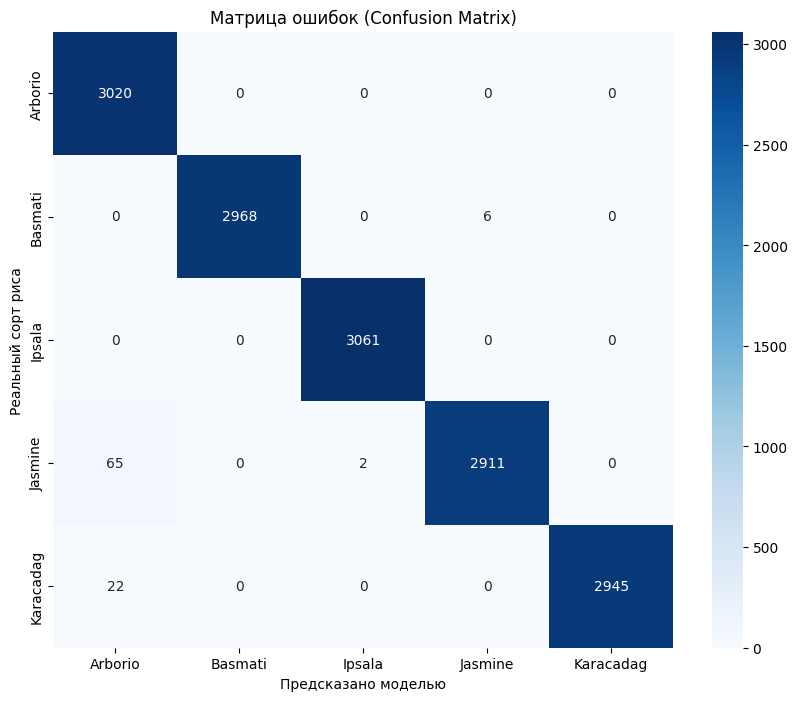

In [13]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

resnet = models.resnet18(weights='DEFAULT')

num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 5)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.Adam(resnet.parameters(), lr=0.0005)

resnet = train_model(resnet, criterion, optimizer_ft, num_epochs=2)

evaluate_model(resnet)

final_evaluation(resnet, val_loader)

In [14]:
print("ViT")
vit = models.vit_b_16(pretrained=True)
num_ftrs = vit.heads.head.in_features
vit.heads.head = nn.Linear(num_ftrs, 5)

optimizer_vit = optim.Adam(vit.parameters(), lr=0.0001)

vit = train_model(vit, criterion, optimizer_vit, num_epochs=2)
evaluate_model(vit)

ViT


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 56.4MB/s]


Epoch 1/2 | Loss: 0.0517 Acc: 0.9828
Epoch 2/2 | Loss: 0.0271 Acc: 0.9917
Validation Accuracy: 0.9949 | Validation F1-Score: 0.9949


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader

train_transforms_improved = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


train_data_improved = ApplyTransform(train_subset, transform=train_transforms_improved)
val_data_stable = ApplyTransform(val_subset, transform=val_transforms)

train_loader = DataLoader(train_data_improved, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data_stable, batch_size=32, shuffle=False)

print("--- Обучение улучшенного ResNet18 ---")
resnet_improved = models.resnet18(weights='DEFAULT')
num_ftrs = resnet_improved.fc.in_features
resnet_improved.fc = nn.Linear(num_ftrs, 5)

optimizer_improved = optim.Adam(resnet_improved.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

resnet_improved = train_model(resnet_improved, criterion, optimizer_improved, num_epochs=3)


evaluate_model(resnet_improved)

--- Обучение улучшенного ResNet18 ---
Epoch 1/3 | Loss: 0.0462 Acc: 0.9846
Epoch 2/3 | Loss: 0.0269 Acc: 0.9913
Epoch 3/3 | Loss: 0.0196 Acc: 0.9937
Validation Accuracy: 0.9890 | Validation F1-Score: 0.9890


In [19]:
import torch.nn.functional as F

class SimpleRiceNet(nn.Module):
    def __init__(self):
        super(SimpleRiceNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 5)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print("CNN")
my_model = SimpleRiceNet()
optimizer_my = optim.Adam(my_model.parameters(), lr=0.001)

my_model = train_model(my_model, criterion, optimizer_my, num_epochs=3)

evaluate_model(my_model)

CNN
Epoch 1/3 | Loss: 0.1044 Acc: 0.9635
Epoch 2/3 | Loss: 0.0420 Acc: 0.9859
Epoch 3/3 | Loss: 0.0304 Acc: 0.9901
Validation Accuracy: 0.9866 | Validation F1-Score: 0.9866


In [21]:
print("--- Обучение улучшенного CNN (SimpleRiceNet) ---")


my_model_final = SimpleRiceNet()
optimizer_final = optim.Adam(my_model_final.parameters(), lr=0.0005)

my_model_final = train_model(my_model_final, criterion, optimizer_final, num_epochs=3)

print("\nРезультат улучшенной собственной модели:")
evaluate_model(my_model_final)

--- Обучение улучшенного CNN (SimpleRiceNet) ---
Epoch 1/3 | Loss: 0.1010 Acc: 0.9652
Epoch 2/3 | Loss: 0.0343 Acc: 0.9886
Epoch 3/3 | Loss: 0.0252 Acc: 0.9915

Результат улучшенной собственной модели:
Validation Accuracy: 0.9964 | Validation F1-Score: 0.9964
